<a href="https://colab.research.google.com/github/sydas13/ML_Lab_Codes/blob/main/Question10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [90]:
from google.colab import files

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    jaccard_score, confusion_matrix, roc_curve, auc
)
from sklearn.impute import SimpleImputer

In [92]:
uploaded = files.upload()

Saving tumor_Data.csv to tumor_Data.csv


In [93]:
df = pd.read_csv('tumor_Data.csv')

df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [94]:
if X.isnull().values.any():
    cols_with_nan = X.columns[X.isnull().any()].tolist()
    if cols_with_nan:
        imputer = SimpleImputer(missing_values=np.nan, strategy='median')
        X[cols_with_nan] = imputer.fit_transform(X[cols_with_nan])

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [96]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [97]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
metrics_list = []
cm_data = {}
roc_data = {}

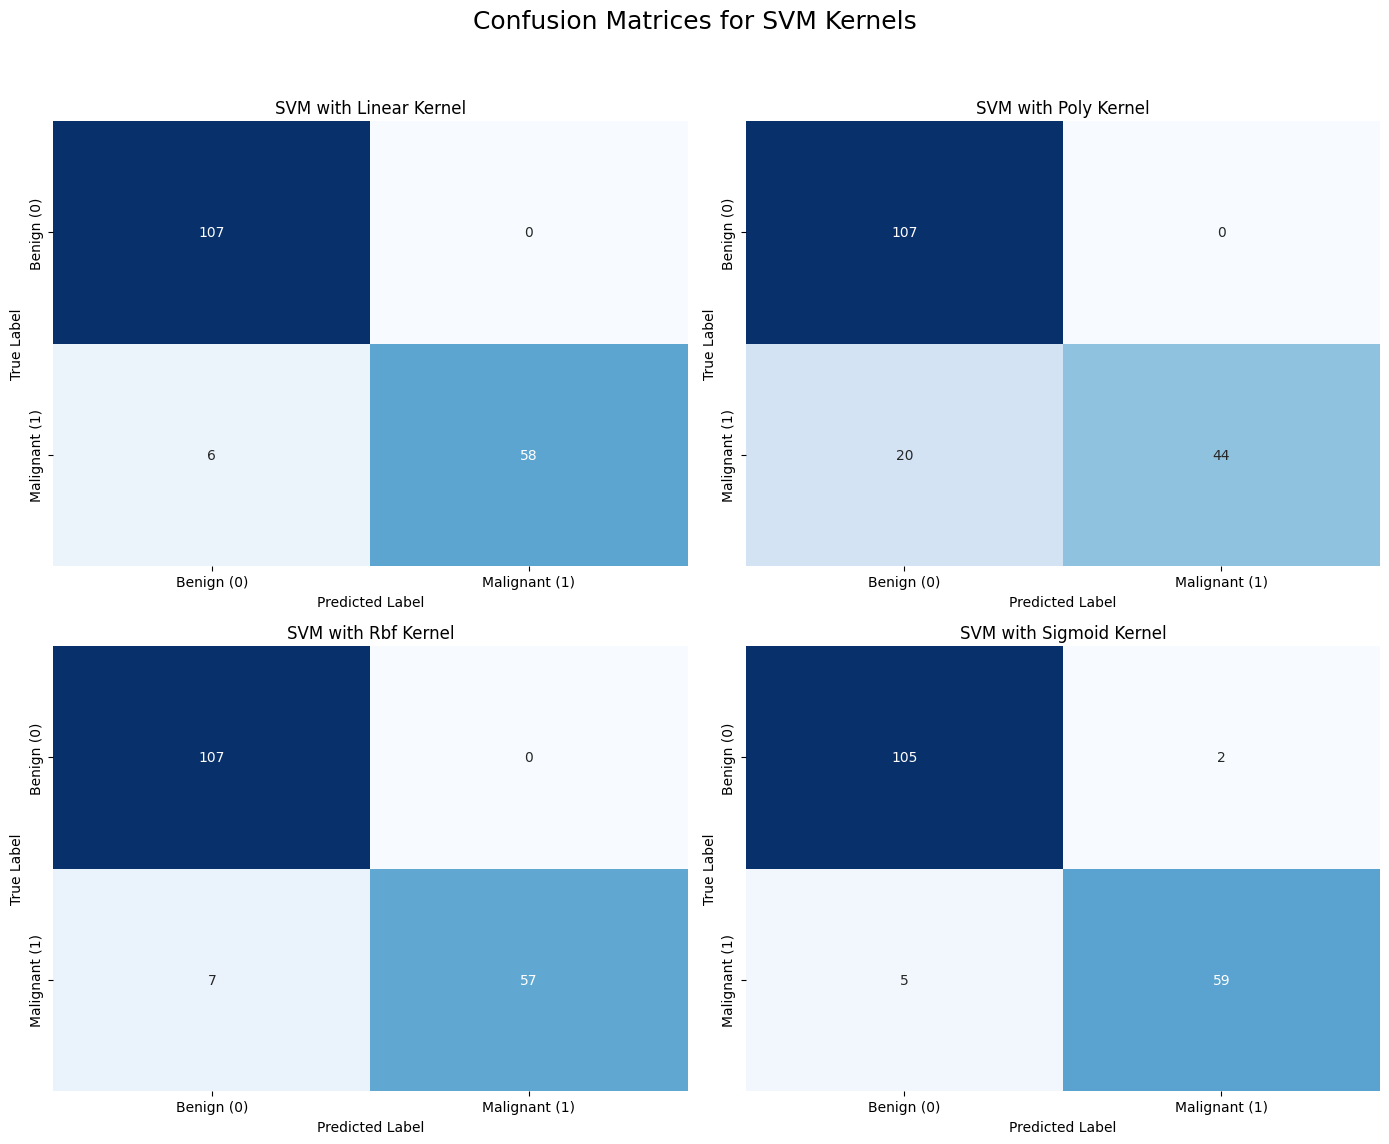

In [98]:
for kernel in kernels:

    svm = SVC(kernel=kernel, probability=True, random_state=42, gamma='scale')
    svm.fit(X_train_scaled, y_train)


    y_pred = svm.predict(X_test_scaled)
    y_prob = svm.predict_proba(X_test_scaled)[:, 1]


    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    jaccard = jaccard_score(y_test, y_pred)
    error_rate = 1 - accuracy


    metrics_list.append({
        'Kernel': kernel.capitalize(),
        'Accuracy': accuracy,
        'Recall': recall,
        'Precision': precision,
        'F1-Score': f1,
        'Jaccard Score': jaccard,
        'Error Rate': error_rate
    })


    cm_data[kernel.capitalize()] = confusion_matrix(y_test, y_pred)


    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[kernel.capitalize()] = (fpr, tpr, roc_auc)


metrics_df = pd.DataFrame(metrics_list)


fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
plt.suptitle('Confusion Matrices for SVM Kernels', fontsize=18)

for i, kernel_name in enumerate(kernels):
    name = kernel_name.capitalize()
    cm = cm_data[name]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Benign (0)', 'Malignant (1)'],
                yticklabels=['Benign (0)', 'Malignant (1)'],
                ax=axes[i])
    axes[i].set_title(f'SVM with {name} Kernel')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('svm_confusion_matrix_heatmaps.png')


In [99]:
plt.close()

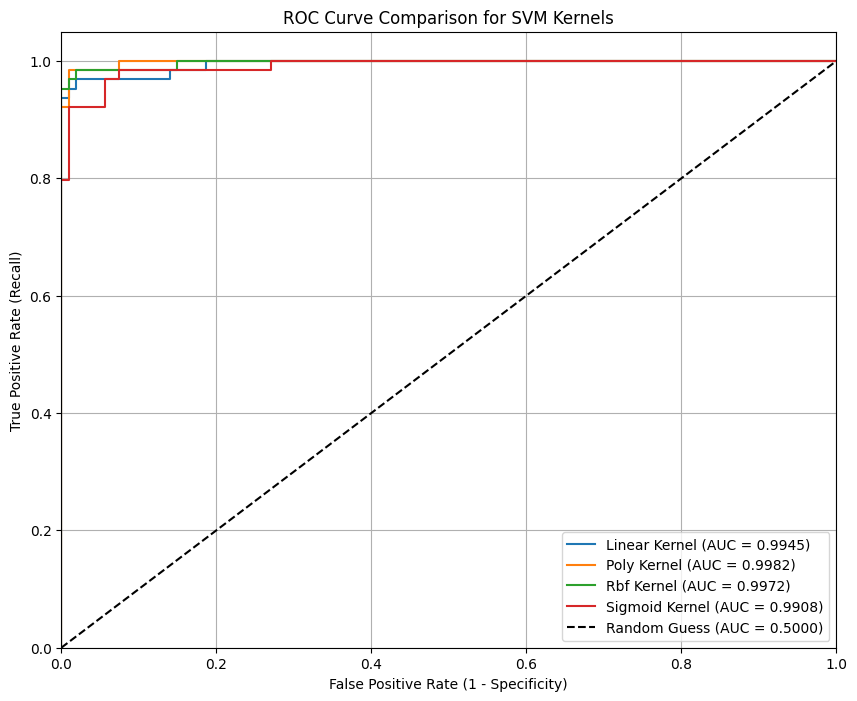

In [100]:
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} Kernel (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison for SVM Kernels')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('svm_roc_curve_comparison.png')

In [101]:
plt.close()